In [60]:
#!pip install albumentations==0.4.6

In [61]:
#!pip install wandb

In [62]:
#from google.colab import drive
#drive.mount('/content/drive')

In [1]:

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.functional as TF

import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader

import numpy as np

#augmentation 
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.auto import tqdm
import torch.optim as optim

from numpy import float32
import torchvision
# To apply transformations to the data (when loaded).
import torchvision.transforms as transforms
import wandb

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

from sklearn.manifold import TSNE
from sklearn import manifold

import torch.nn.functional as F


In [64]:
wandb.login(key="e3a44ac8e966c38d38fc008f8c96dd5c0d1760c3")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publically.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Steven/.netrc


True

# Hyperparameters

In [3]:
# About metrics.
# Metric dictionary keys 
_loss_train          = 'Loss Training'
_loss_val            = 'Loss Validation'
contador = 0

# Get a clean dictionary for the metrics.
def getMetricsDict():
    return {
        _loss_train     : torch.tensor(0.),
        _loss_val       : torch.tensor(0.)
    }
classes = [
        'Apple - Apple scab',
        'Apple - Black rot',
        'Apple - Cedar apple rust',
        'Apple - Healthy',
        'Background without leaves',
        'Blueberry - Healthy',
        'Cherry - Healthy',
        'Cherry - Powdery mildew',
        'Corn - Cercospora',
        'Corn - Common rust',
        'Corn - Healthy',
        'Corn - Northern Leaf Blight',
        'Grape - Black rot',
        'Grape - Esca',
        'Grape - Healthy',
        'Grape - Leaf blight',
        'Orange - Haunglongbing',
        'Peach - Bacterial spot',
        'Peach - Healthy',
        'Pepper bell - Bacterial spot',
        'Pepper bell - healthy',
        'Potato - Early blight',
        'Potato - Healthy',
        'Potato - Late blight',
        'Raspberry - healthy',
        'Soybean - Healthy',
        'Squash - Powdery mildew',
        'Strawberry - Healthy',
        'Strawberry - Leaf scorch',
        'Tomato - Bacterial spot',
        'Tomato - Early blight',
        'Tomato - Healthy',
        'Tomato - Late blight',
        'Tomato - Leaf Mold',
        'Tomato - Septoria leaf spot',
        'Tomato - Spider mites',
        'Tomato - Target Spot',
        'Tomato - Mosaic virus',
        'Tomato - Yellow Leaf Curl Virus'
    ]

### Transforms

In [4]:
LEARNING_RATE       = "LEARNING_RATE"
DEVICE              = "DEVICE" 
BATCH_SIZE          = "BATCH_SIZE"
NUM_EPOCHS          = "NUM_EPOCHS"
NUM_WORKERS         = "NUM_WORKERS"
NUM_CHANNELS        = "NUM_CHANNELS"
NUM_CLASSES         = "NUM_CLASSES"
IMAGE_HEIGHT        = "IMAGE_HEIGHT"
IMAGE_WIDTH         = "IMAGE_WIDTH" 
PIN_MEMORY          = "PIN_MEMORY"
LOAD_MODEL          = "LOAD_MODEL"
TRAIN_IMG_DIR       = "TRAIN_IMG_DIR"
TRAIN_MASK_DIR      = "TRAIN_MASK_DIR"
VAL_IMG_DIR         = "VAL_IMG_DIR"
VAL_MASK_DIR        = "VAL_MASK_DIR"
TRAIN_CLASS_IMG_DIR = "TRAIN_CLASS_IMG_DIR"
VAL_CLASS_IMG_DIR   = "VAL_CLASS_IMG_DIR"
TSNE_CLASS_IMG_DIR  = "TSNE_CLASS_IMG_DIR"
TRANSFORM_TRAIN     = "TRANSFORM_TRAIN"
TRANSFORM_VAL       = "TRANSFORM_VAL"
RUN_NAME            = "RUN_NAME"
SAVE_MODEL_FILENAME = "SAVE_MODEL_FILENAME"
SAVE_MODEL_IMAGES   = "SAVE_MODEL_IMAGES"
TRANSFORM_TSNE      = "TRANSFORM_TSNE"
CLASSES             = "CLASSES"
CLASSES_ID          = "CLASSES_ID"
CLASSES_LEN         = "CLASSES_LEN"

config={
LEARNING_RATE       : 1e-4,
DEVICE              : "cuda" if torch.cuda.is_available() else "cpu",
BATCH_SIZE          : 32,
NUM_EPOCHS          : 2,
NUM_WORKERS         : 0,
NUM_CHANNELS        : 3,
NUM_CLASSES         : 3,
IMAGE_HEIGHT        : 224,
IMAGE_WIDTH         : 224,
PIN_MEMORY          : True,
LOAD_MODEL          : False,
CLASSES             : classes,
CLASSES_ID : [i + 1 for i in range(len(classes))],
CLASSES_LEN : len(classes),
#Data path for Autoencoder
TRAIN_IMG_DIR       : "G:/Mi unidad//plants/train",
TRAIN_MASK_DIR      : "G:/Mi unidad//plants/train",
VAL_IMG_DIR         : "G:/Mi unidad//plants/val",
VAL_MASK_DIR        : "G:/Mi unidad//plants/val_masks",
SAVE_MODEL_FILENAME : "G:/Mi unidad/resUnett/model/model.pth.tar",
SAVE_MODEL_IMAGES   : "G:/Mi unidad/resUnett/images/",
TSNE_CLASS_IMG_DIR  : "G:/Mi unidad/resUnett/corrida2_1",

#TRAIN_IMG_DIR       : "/content/drive/MyDrive/resUnet/corrida2_1/noLabel(noDirs)",
#TRAIN_MASK_DIR      : "/content/drive/MyDrive/resUnet/corrida2_1/noLabel(noDirs)",
#VAL_IMG_DIR         : "/content/drive/MyDrive/resUnet/corrida2_1/valNoLabel(NoDirs)",
#VAL_MASK_DIR        : "/content/drive/MyDrive/resUnet/corrida2_1/valNoLabel(NoDirs)",
#SAVE_MODEL_FILENAME : "/content/drive/MyDrive/resUnet/corrida2_1/model/model.pth.tar",
#SAVE_MODEL_IMAGES   : "/content/drive/MyDrive/resUnet/corrida2_1/images/",
#TSNE_CLASS_IMG_DIR  : "/content/drive/MyDrive/resUnet/corrida2_1",
#Transforms
TRANSFORM_TRAIN     : None,
TRANSFORM_VAL       : None,
TRANSFORM_TSNE      : None,
RUN_NAME            : f"Corrida 2 -224 - {contador}",
TRAIN_CLASS_IMG_DIR : "G:/Mi unidad/plants/classifier_train",
VAL_CLASS_IMG_DIR   : "G:/Mi unidad/plants/classifier_train"
}

In [67]:
train_transform = A.Compose([
    A.Resize(height=config[IMAGE_HEIGHT], width=config[IMAGE_WIDTH]),
    A.Rotate(limit=35, p=1.0),
    A.HorizontalFlip(p=0.1),
    A.Normalize(
        mean=[0.0, 0.0, 0.0],
        std=[1.0, 1.0, 1.0],
        max_pixel_value=255.0,
    ),
    # B H W C
    # B C H W 
    ToTensorV2(),
    #TODO change if is a gray scale image
],additional_targets={'image': 'image', 'mask': 'image'})

val_transform = A.Compose([
    A.Resize(height=config[IMAGE_HEIGHT], width=config[IMAGE_WIDTH]),
    A.Normalize(
        mean=[0.0, 0.0, 0.0],
        std=[1.0, 1.0, 1.0],
        max_pixel_value=255.0,
    ),
    ToTensorV2(),
    #TODO
],additional_targets={'image': 'image', 'mask': 'image'})

tsne_transform = transforms.Compose([
        transforms.Resize((config[IMAGE_HEIGHT], config[IMAGE_WIDTH])),
        transforms.ToTensor(),                            # Make the image a tensor.
        transforms.Normalize(
            [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Expected normalization for pretrained pytorch models.
    ])

config[TRANSFORM_TRAIN] = train_transform
config[TRANSFORM_VAL] = val_transform
config[TRANSFORM_TSNE] = tsne_transform

# Utils

In [5]:
def save_checkpoint(state, filename="my_checkpoint.pth.tar"):
  print("=> Saving checkpoint")
  torch.save(state, filename)

def load_checkpoint(checkpoint, model):
  print("=> Loading checkpoint")
  model.load_state_dict(checkpoint["state_dict"])

def get_loaders(
    train_dir,
    train_maskdir,
    val_dir,
    val_maskdir,
    batch_size,
    train_transform,
    val_transform,
    num_workers=4,
    pin_memory=True,
):
  train_ds = PlantsDataset(
      image_dir = train_dir,
      mask_dir  = train_maskdir,
      transform = train_transform, 
  )
  train_loader = DataLoader(
      train_ds,
      batch_size=batch_size,
      num_workers=num_workers,
      pin_memory=pin_memory,
      shuffle=True,
  )

  val_ds = PlantsDataset(
      image_dir = val_dir,
      mask_dir  = val_maskdir,
      transform = val_transform, 
  )
  val_loader = DataLoader(
      val_ds,
      batch_size=batch_size,
      num_workers=num_workers,
      pin_memory=pin_memory,
      shuffle=False,
  )

  return train_loader, val_loader

#TODO Change the accuracy metric for RBG image.
def check_val(loader, model, loss_fn, device="cuda"):
  model.eval()
  totalLoss = 0
  with torch.no_grad():
    for i, (data, targets) in enumerate(loader):
      data = data.to(config[DEVICE])

      if config[NUM_CLASSES] > 1:
        targets = targets.float().to(config[DEVICE])
      else:
        targets = targets.float().unsqueeze(1).to(config[DEVICE])

    with torch.cuda.amp.autocast():
      predictions = model(data)
      predictions = predictions.float().to(config[DEVICE])
      loss = loss_fn(predictions, targets)
      totalLoss += loss.item()/len(loader)
  model.train()
  return totalLoss

def save_tsne(loader, model, folder="saved_images/", device="cuda", epoch=0):
  model.eval()
  pred_acc = torch.tensor(())
  labels_acc = torch.tensor(())

  for idx, (images, labels) in enumerate(loader):
      images = images.to(config[DEVICE])
      pred_acc = torch.cat((pred_acc, model(images)), 0)
      labels_acc = torch.cat((labels_acc, labels), 0)

      if idx == 10:
        break;

  Y = TorchTSNE(n_components=2, perplexity=20.0, n_iter=2000, initial_dims = 1024,   verbose=False).fit_transform(pred_acc)
  plt.scatter(Y[:, 0], Y[:, 1], c=labels_acc)
  plt.savefig(f"{folder}/epoch_TSNE_{epoch}.png")

def save_predictions_as_imgs(loader, model, folder="saved_images/", device="cuda", epoch=0):
  model.eval()
  for idx, (x, y) in enumerate(loader):
    x = x.to(device)
    with torch.no_grad():
      preds = model(x)
      torchvision.utils.save_image(preds, f"{folder}/epoch_{epoch}_pred_{idx}.png")
      if config[NUM_CLASSES] > 1:
        torchvision.utils.save_image(y, f"{folder}/epoch_{epoch}_y_{idx}.png")
      else:
        torchvision.utils.save_image(y.unsqueeze(1), f"{folder}/epoch_{epoch}_y_{idx}.png")

def kernel_size(initial_value, iterations, division_value=2):
  for i in range(iterations):
    initial_value//=division_value
  return initial_value


# Model 

In [11]:
class DoubleConv(nn.Module):
  def __init__ (self, in_channels, out_channels):
    super(DoubleConv, self).__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
        #Here we add Batch Normalization to improve the paper's model
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
        #Here we add Batch Normalization to improve the paper's model
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )

  def forward(self, x):
    return self.conv(x)
      

In [24]:
class UNET(nn.Module):
  #features represent the original paper dimensions.
  def encoder(self, x):
    #For save the connections with the up part
    skip_connections = []
    for down in self.downs:
      x = down(x)
      print("Down")
      print(x.shape)
      skip_connections.append(x)
      x = self.pool(x)
      print("Pooling")
      print(x.shape)
    #Here is the bottom part of the net
    x = self.bottleneck(x)
    print("Bottleneck")
    print(x.shape)
    x = torch.flatten(x, start_dim=1)
    print("Flatten")
    print(x.shape)
    x = self.linear1(x)
    print("Linear")
    print(x.shape)
    return (skip_connections, x)

  def decoder(self, skip_connections, x):
    x = self.linear2(x)
    x = x.reshape((x.shape[0], self.features[-1] *2 , self.kernelHeight, self.kernelWidth))
    #Start the up part
    #Reverse list
    skip_connections = skip_connections[:: -1]

    #Step of two because we use up and doubleconv
    #0 is the up
    #1 is the double conv
    for idx in range (0, len(self.ups), 2):
      x = self.ups[idx](x)
      #Divide idx by 2 for going liner with the skip connections
      skip_connection = skip_connections[idx//2]

      #General solutions for image tha not are divisibles
      if x.shape != skip_connection.shape:
        #Take the H and W, skip the Batch Size and Channels
        x = TF.resize(x, size=skip_connection.shape[2:])
      #Add the skip connection
      concat_skip = torch.cat((skip_connection, x), dim=1)
      # (e.g 0 +1 for the doubleconv)
      x = self.ups[idx+1](concat_skip)
    return self.final_conv(x)

  def __init__(self, in_channels=3, out_channels=1, features=[8, 16, 32, 64, 128, 256] , linearFeature=1024,isOnlyEncoder=False):
    super(UNET, self).__init__()
    self.linearFeature = linearFeature
    self.isOnlyEncoder = isOnlyEncoder
    self.latentVector = None
    #Encoder part
    self.downs = nn.ModuleList()
    #Decoder part
    self.ups = nn.ModuleList()
    #Pool
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
    self.features = features
    self.kernelHeight = kernel_size(config[IMAGE_HEIGHT], len(self.features))
    self.kernelWidth = kernel_size(config[IMAGE_WIDTH], len(self.features))
    self.kernelSize = self.kernelHeight * self.kernelWidth

   #Create a list of contracting path
    for feature in features:
      self.downs.append(DoubleConv(in_channels, feature))
      in_channels = feature

   #Create a list of expansive path
    for feature in reversed(features):
      self.ups.append(
         #Featur2 * 2 is to create the 1024 dim
         nn.ConvTranspose2d(feature *2, feature, kernel_size=2, stride=2,)
     )
      self.ups.append(DoubleConv(feature * 2, feature))
  
    self.bottleneck = DoubleConv(features[-1], features[-1]*2)

    self.linear1 = nn.Linear(self.features[-1]*2*self.kernelSize,  self.linearFeature)
    self.linear2 = nn.Linear(self.linearFeature, features[-1]*2*self.kernelSize)

    self.final_conv = nn.Conv2d(self.features[0], out_channels, kernel_size=1)

  def forward(self, x):
    (skip_connections, self.latentVector) = self.encoder(x)
    #Check if we are using only de encoder part
    if self.isOnlyEncoder:
      return self.latentVector
    x = self.decoder(skip_connections, self.latentVector)
    return x
    
    
   


In [16]:
class Autoencoder(nn.Module):
  #features represent the original paper dimensions.}
  def encoder(self, x):
      for down in self.downs:
          x = down(x)
          print("Down")
          print(x.shape)
          x = self.pool(x)
          print("Pooling")
          print(x.shape)
      x = torch.flatten(x, start_dim=1)
      print("Flatten")
      print(x.shape)
      x = self.FC1(x)
      print("Latent")
      print(x.shape)
      return x

  def decoder(self, x):
    x = self.FC2(x)
    x = x.reshape((x.shape[0], self.features[-1] , self.kernelHeight, self.kernelWidth))
    print("After Reshape")
    print(x.shape)
    #x = self.ups[0](x)
    #print("X1")
    #print(x.shape)
    #x = F.pad(input=x, pad=(0, 1, 1, 0), mode='constant', value=0)
    for idx in range(0, len(self.ups)):
      x = self.ups[idx](x)
      print("X1")
      print(x.shape)
      
    #x = self.final_conv(x)
    #print("Final conv")
    #print(x.shape)
    return x

  def __init__(self, in_channels=3, out_channels=1, features=[16, 32, 64, 128, 256] , latentVectorSize=128,isOnlyEncoder=False):
    super(Autoencoder, self).__init__()
    self.isOnlyEncoder = isOnlyEncoder
    #Encoder part
    self.downs = nn.ModuleList()
    #Decoder part
    self.ups = nn.ModuleList()
    #Pool
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
    self.features = features
    self.kernelHeight = kernel_size(config[IMAGE_HEIGHT], len(self.features))
    self.kernelWidth = kernel_size(config[IMAGE_WIDTH], len(self.features))
    self.kernelSize = self.kernelHeight * self.kernelWidth

    self.latentVectorSize = latentVectorSize
    self.latentVector = 0
    self.FC1 = nn.Linear(self.features[-1]*self.kernelSize,  self.latentVectorSize)
    self.FC2 = nn.Linear(self.latentVectorSize ,self.features[-1]*self.kernelSize)

   #Create a list of contracting path
    for feature in features:
      self.downs.append(DoubleConv(in_channels, feature))
      in_channels = feature

   #Create a list of expansive path
    for i in range(len(features)-1, 1, -1):
        #print(i)
        #print(features[i])
        #print(features[i-1])
        self.ups.append(
            nn.ConvTranspose2d(features[i], features[i-1], kernel_size=2, stride=2,)
            )
    self.ups.append(nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2))
    self.ups.append(nn.ConvTranspose2d(features[0], features[0]//2, kernel_size=2, stride=2))
    self.ups.append(DoubleConv(features[0]//2 , out_channels))

  def forward(self, x):
   self.latentVector = self.encoder(x)
   if self.isOnlyEncoder:
       return self.latentVector
   return self.decoder(self.latentVector)
    
    

In [25]:
def test():
  #Batch, Channel, H, W
  x = torch.randn((5,3,config[IMAGE_HEIGHT],config[IMAGE_WIDTH]))
  model = UNET(in_channels=3,out_channels=3, isOnlyEncoder=False)
  preds = model(x)
  print(preds.shape)
  print(x.shape)

  assert preds.shape == x.shape

test()

Down
torch.Size([5, 8, 224, 224])
Pooling
torch.Size([5, 8, 112, 112])
Down
torch.Size([5, 16, 112, 112])
Pooling
torch.Size([5, 16, 56, 56])
Down
torch.Size([5, 32, 56, 56])
Pooling
torch.Size([5, 32, 28, 28])
Down
torch.Size([5, 64, 28, 28])
Pooling
torch.Size([5, 64, 14, 14])
Down
torch.Size([5, 128, 14, 14])
Pooling
torch.Size([5, 128, 7, 7])
Down
torch.Size([5, 256, 7, 7])
Pooling
torch.Size([5, 256, 3, 3])
Bottleneck
torch.Size([5, 512, 3, 3])
Flatten
torch.Size([5, 4608])
Linear
torch.Size([5, 1024])
torch.Size([5, 3, 224, 224])
torch.Size([5, 3, 224, 224])


# Load PlantsDataset

In [7]:
class PlantsDataset(Dataset):
  def __init__(self, image_dir, mask_dir, transform=None):
    self.image_dir = image_dir
    self.mask_dir = mask_dir
    self.transform = transform
    self.images = os.listdir(self.image_dir)

  def __len__(self):
    return len(self.images)
  
  def __getitem__(self, index):
     img_path = os.path.join(self.image_dir, self.images[index])
    #  mask_path = os.path.join(self.mask_dir, self.images[index].replace(".jpg", "_mask.gif"))
     mask_path = os.path.join(self.mask_dir, self.images[index])
     
     image = np.array(Image.open(img_path).convert("RGB"))
     mask = np.array(Image.open(mask_path).convert("RGB"))
     
     if self.transform is not None:
       augmentations = self.transform(image=image, mask=mask)
       image = augmentations["image"]
       mask = augmentations["mask"]
     return image, mask

In [8]:
def getLoaderTsne(rootPath):
    testPath  = os.path.join(rootPath, 'labelTest')

    # Get the training and test data, apply the transformations.
    testset  = torchvision.datasets.ImageFolder(root=testPath,  transform=config[TRANSFORM_TSNE])

    testloader  = torch.utils.data.DataLoader(testset,  batch_size=config[BATCH_SIZE], shuffle=True, num_workers=config[NUM_WORKERS])
    
    return testloader

# Training 

In [75]:
#Do 1 epoch training
def train_fn(val_loader, train_loader, model, optimizer, loss_fn, scaler):
  
  loop = tqdm(train_loader)
  total_loss = 0
  for batch_idx, (data, targets) in enumerate (loop):
    metricsResults = getMetricsDict()
    model.train()
    data = data.to(config[DEVICE])
    #For the Binary Cross Entropy using must be a float
    #Unsqueese is for adding a channel dimension.
    if config[NUM_CLASSES] > 1:
      targets = targets.float().to(config[DEVICE])
    else:
      targets = targets.float().unsqueeze(1).to(config[DEVICE])
    

    #Forward
    #Run with mixture precision float 32 ops with float16 and stuffs like that.
    with torch.cuda.amp.autocast():
      if config[NUM_CLASSES] > 1:
        predictions = model(data)
        predictions = predictions.float().to(config[DEVICE])
        loss = loss_fn(predictions, targets)
        total_loss += loss / len(loop)
    #Backwards
    optimizer.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optimizer=optimizer)
    scaler.update()
    #update tqdm loop
    
    if ((batch_idx) % 100 == 0):
      checkpoint = {
        "state_dict"  : model.state_dict(),
        "optimizer"   : optimizer.state_dict()
      }
      print(f"Loss training batch {batch_idx} val : {loss.item()}")
      save_checkpoint(checkpoint, filename=config[SAVE_MODEL_FILENAME])
      save_predictions_as_imgs(val_loader, model, folder=config[SAVE_MODEL_IMAGES],
      device=config[DEVICE], epoch=batch_idx)
      save_tsne(tsne_loader, model, folder=config[SAVE_MODEL_IMAGES], device=config[DEVICE], epoch=batch_idx)
    
    metricsResults[_loss_train]  = loss.item()
    wandb.log(metricsResults)
    loop.set_postfix(loss=loss.item())

  return total_loss

def train(train_loader, model, optimizer, loss, metricsResults):
  #Progress bar
  
  scaler = torch.cuda.amp.GradScaler()
  for epoch in range(config[NUM_EPOCHS]):
    model.train()
    lossTrain = train_fn(val_loader, train_loader, model, optimizer, loss, scaler)
    #update tqdm loop
    #checkpoint = {
    #    "state_dict"  : model.state_dict(),
    #    "optimizer"   : optimizer.state_dict()
    #}
    #if (epoch % 20 == 0):
    #  save_checkpoint(checkpoint, filename=config[SAVE_MODEL_FILENAME])
    #  save_predictions_as_imgs(val_loader, model, folder=config[SAVE_MODEL_IMAGES],
    #  device=config[DEVICE], epoch=epoch)
    #Check
    #lossVal = check_val(val_loader, model, loss, device=config[DEVICE])
    #metricsResults[_loss_train]  = lossTrain
    #metricsResults[_loss_val]    = lossVal
    #print(f"Loss training : {lossTrain}, Loss validation : {lossVal}")
    #wandb.log(metricsResults)
   

    

In [76]:
train_loader, val_loader = get_loaders(
    config[TRAIN_IMG_DIR]   ,
    config[TRAIN_MASK_DIR]  ,
    config[VAL_IMG_DIR]     ,
    config[VAL_MASK_DIR]    ,
    config[BATCH_SIZE]      ,
    config[TRANSFORM_TRAIN] ,
    config[TRANSFORM_VAL]   ,
    config[NUM_WORKERS]     ,
    config[PIN_MEMORY]      
)

tsne_loader = getLoaderTsne(config[TSNE_CLASS_IMG_DIR])

FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: 'G:/Mi unidad/resUnet/corrida2_1\\labelTest'

## Create model

In [17]:
#model = UNET(in_channels=config[NUM_CHANNELS], out_channels=config[NUM_CLASSES]).to(config[DEVICE])
model = Autoencoder(in_channels=3,out_channels=3, isOnlyEncoder=False)
#With Logits because the model has not activation function
if config[NUM_CLASSES] > 1:
  loss = nn.MSELoss()
else:
  loss = nn.BCEWithLogitsLoss()

#Optimizer
optimizer = optim.Adam(model.parameters(), lr=config[LEARNING_RATE])



#Check if we have to load a model
if config[LOAD_MODEL]:
  load_checkpoint(torch.load(config[SAVE_MODEL_FILENAME], map_location=config[DEVICE]), model)
  check_val(val_loader, model, loss, device=config[DEVICE])

#Training...
# Init wandb
run = wandb.init(project='Unet', entity='tecai', config=config, name=config[RUN_NAME])
metricsResults = getMetricsDict()
train(train_loader, model, optimizer, loss, metricsResults)
#Loader
# Finish wandb
run.finish()


C:\Users\Steven\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\cuda\amp\grad_scaler.py:116: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn("torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.")
  0%|          | 0/3 [00:00<?, ?it/s]C:\Users\Steven\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\cuda\amp\autocast_mode.py:118: UserWarning: torch.cuda.amp.autocast only affects CUDA ops, but CUDA is not available.  Disabling.
  warnings.warn("torch.cuda.amp.autocast only affects CUDA ops, but CUDA is not available.  Disabling.")
Loss training batch 0 val : 0.2778252959251404
=> Saving checkpoint
  0%|          | 0/3 [00:40<?, ?it/s]Exception ignored in: <generator object tqdm.__iter__ at 0x00000226C0040660>
Traceback (most recent call last):
  File "C:\Users\Steven\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\std.py", line 1193, in __iter__
    self.close()
  F

KeyboardInterrupt: 

In [ ]:
save_predictions_as_imgs(val_loader, model, folder=config[SAVE_MODEL_IMAGES],
      device=config[DEVICE], epoch=965)

/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:477: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


In [7]:
samples = torch.rand((256,3))


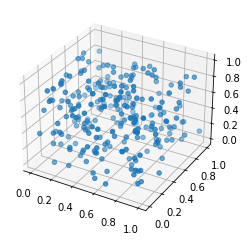

In [8]:

plt.show()

In [97]:
import torch.nn.functional as F

# now we expand to size (7, 11) by appending a row of 0s at pos 0 and pos 6, 
# and a column of 0s at pos 10
result = F.pad(input=source, pad=(0, 1, 1, 0), mode='constant', value=0)
print(result.shape)

torch.Size([32, 512, 7, 7])


In [121]:
import torch
import torch.nn.functional as F
from torch.autograd import Variable
import numpy as np
from math import exp

def gaussian(window_size, sigma):
    gauss = torch.Tensor([exp(-(x - window_size//2)**2/float(2*sigma**2)) for x in range(window_size)])
    return gauss/gauss.sum()

def create_window(window_size, channel):
    _1D_window = gaussian(window_size, 1.5).unsqueeze(1)
    _2D_window = _1D_window.mm(_1D_window.t()).float().unsqueeze(0).unsqueeze(0)
    window = Variable(_2D_window.expand(channel, 1, window_size, window_size).contiguous())
    return window

def _ssim(img1, img2, window, window_size, channel, size_average = True):
    mu1 = F.conv2d(img1, window, padding = window_size//2, groups = channel)
    mu2 = F.conv2d(img2, window, padding = window_size//2, groups = channel)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1*mu2

    sigma1_sq = F.conv2d(img1*img1, window, padding = window_size//2, groups = channel) - mu1_sq
    sigma2_sq = F.conv2d(img2*img2, window, padding = window_size//2, groups = channel) - mu2_sq
    sigma12 = F.conv2d(img1*img2, window, padding = window_size//2, groups = channel) - mu1_mu2

    C1 = 0.01**2
    C2 = 0.03**2

    ssim_map = ((2*mu1_mu2 + C1)*(2*sigma12 + C2))/((mu1_sq + mu2_sq + C1)*(sigma1_sq + sigma2_sq + C2))

    if size_average:
        return ssim_map.mean()
    else:
        return ssim_map.mean(1).mean(1).mean(1)

class SSIM(torch.nn.Module):
    def __init__(self, window_size = 11, size_average = True):
        super(SSIM, self).__init__()
        self.window_size = window_size
        self.size_average = size_average
        self.channel = 1
        self.window = create_window(window_size, self.channel)

    def forward(self, img1, img2):
        (_, channel, _, _) = img1.size()

        if channel == self.channel and self.window.data.type() == img1.data.type():
            window = self.window
        else:
            window = create_window(self.window_size, channel)
            
            if img1.is_cuda:
                window = window.cuda(img1.get_device())
            window = window.type_as(img1)
            
            self.window = window
            self.channel = channel


        return _ssim(img1, img2, window, self.window_size, channel, self.size_average)

def ssim(img1, img2, window_size = 11, size_average = True):
    (_, channel, _, _) = img1.size()
    window = create_window(window_size, channel)
    
    if img1.is_cuda:
        window = window.cuda(img1.get_device())
    window = window.type_as(img1)
    
    return _ssim(img1, img2, window, window_size, channel, size_average)

In [128]:

import torch
import torch.nn as nn

class NIMA(nn.Module):

    """Neural IMage Assessment model by Google"""
    def __init__(self, base_model, num_classes=10):
        super(NIMA, self).__init__()
        self.features = base_model.features
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.75),
            nn.Linear(in_features=25088, out_features=num_classes),
            nn.Softmax())

    def forward(self, x):
        out = self.features(x)
        out = out.view(out.size(0), -1)
        out = self.classifier(out)
        return out


def single_emd_loss(p, q, r=2):
    """
    Earth Mover's Distance of one sample
    Args:
        p: true distribution of shape num_classes × 1
        q: estimated distribution of shape num_classes × 1
        r: norm parameter
    """
    assert p.shape == q.shape, "Length of the two distribution must be the same"
    length = p.shape[0]
    emd_loss = 0.0
    for i in range(1, length + 1):
        emd_loss += torch.abs(sum(p[:i] - q[:i])) ** r
    return (emd_loss / length) ** (1. / r)


def emd_loss(p, q, r=2):
    """
    Earth Mover's Distance on a batch
    Args:
        p: true distribution of shape mini_batch_size × num_classes × 1
        q: estimated distribution of shape mini_batch_size × num_classes × 1
        r: norm parameters
    """
    assert p.shape == q.shape, "Shape of the two distribution batches must be the same."
    mini_batch_size = p.shape[0]
    loss_vector = []
    for i in range(mini_batch_size):
        loss_vector.append(single_emd_loss(p[i], q[i], r=r))
    return sum(loss_vector) / mini_batch_size

In [130]:
model = Autoencoder(in_channels=3,out_channels=3, isOnlyEncoder=False)

source = torch.rand((32,3, 224, 224))
source2 = torch.rand((32,3, 224, 224))
s = NIMA(model)
s(source, source2)

TypeError: forward() takes 2 positional arguments but 3 were given